# CISC7204 Assignment 01 — Module 04 / Lab 01: Car model development

**Submitted by:** Xiji Hang (MC646933).

**Laboratory collaborators:** Xiji Hang (MC646933) and Xiaoyu Guo (MC648131).  
**Collaboration:** All laboratory work is undertaken jointly by both students.

**Data:** [automobileEDA.csv](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/Data%20files/automobileEDA.csv). Each row is an automobile record; the target is price in USD. Highway fuel economy is in mpg; engine speed is in rpm.
The supplied educational snapshot is loaded independently from `../datasets/raw/automobileEDA.csv`;
it is not assumed to be identical to an earlier laboratory's exported data. Raw data are preserved.

**Evaluation scope:** All model scores in this notebook are in-sample fit measures, not held-out predictive performance.

**Local adaptation:** This working copy runs in local Anaconda/Jupyter. Browser-only
installation/download cells are replaced with local imports and data paths. Supplied solution
dropdowns and stale example answers are omitted; the original template remains unchanged.
Numbered questions and their order are retained. IBM template authorship and attribution appear below.

**AI acknowledgement:** [OpenAI Codex](https://openai.com/codex/) was used for coding,
debugging and wording assistance. Numerical results were produced by executing this notebook.

<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="300" alt="Skills Network Logo">
    </a>
</p>


# Model Development


Estimated time needed: **30** minutes
    

## Objectives

After completing this lab you will be able to:

* Develop prediction models


<p>In this section, we will develop several models that will predict the price of the car using the variables or features. This is just an estimate but should give us an objective idea of how much the car should cost.</p>


A regression model estimates associations in the observed sample. It does not identify an exact causal relationship or establish a fair current market valuation.

<h4>Setup</h4>


 Import libraries:


The required libraries are already installed in the local Anaconda environment. Versions are printed below; this notebook does not install packages while running.

In [1]:
# Figures use 300 DPI for readable high-resolution exports.
# Regression plots use seed=1 only for reproducible bootstrap confidence bands.
from pathlib import Path
import hashlib
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from IPython.display import display, Markdown
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import (train_test_split, cross_val_score,
                                    cross_val_predict, GridSearchCV)
%matplotlib inline
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.figsize': (7.2, 4.2), 'figure.dpi': 300,
                     'axes.titlesize': 12, 'axes.labelsize': 11,
                     'legend.fontsize': 9, 'figure.constrained_layout.use': True})
pd.set_option('display.max_columns', 8)
pd.set_option('display.precision', 4)
print(f'Python {sys.version.split()[0]} | pandas {pd.__version__} | '
      f'NumPy {np.__version__} | scikit-learn {sklearn.__version__} | '
      f'seaborn {sns.__version__} | matplotlib {matplotlib.__version__}')

def density_plot(actual, predicted, title):
    fig, ax = plt.subplots()
    sns.kdeplot(x=actual, label='Observed', color='#1c768f', ax=ax)
    sns.kdeplot(x=predicted, label='Fitted', color='#df6b37', ax=ax)
    ax.set(title=title, xlabel='Price (USD)', ylabel='Density (1/USD)')
    ax.legend()
    plt.show()

def locate_dataset(filename):
    # Accept a flat submission, the bundle root, or the notebooks subfolder.
    folders = (Path.cwd(), Path.cwd() / 'datasets' / 'raw',
               Path.cwd().parent / 'datasets' / 'raw')
    for folder in folders:
        candidate = folder / filename
        if candidate.is_file():
            return candidate.resolve()
    searched = ', '.join(str(folder / filename) for folder in folders)
    raise FileNotFoundError(f'Missing required dataset {filename}. Searched: {searched}')

def output_root_for(data_file):
    folder = data_file.resolve().parent
    if folder.name == 'raw' and folder.parent.name == 'datasets':
        return folder.parent.parent
    return folder

def metrics_row(label, actual, predicted):
    assert np.isfinite(predicted).all(), 'Predictions must be finite.'
    return {'Model': label, 'R²': r2_score(actual, predicted),
            'MSE (USD²)': mean_squared_error(actual, predicted)}

Python 3.14.6 | pandas 3.0.3 | NumPy 2.4.6 | scikit-learn 1.9.0 | seaborn 0.13.2 | matplotlib 3.11.0


In [2]:
# All required imports are grouped in the preceding local setup cell.

Load the data and store it in dataframe `df`:


The source snapshot has been downloaded once and preserved locally. The next cell records the source and verifies the local file.

In [3]:
source_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/Data%20files/automobileEDA.csv'
file_name = locate_dataset('automobileEDA.csv')
assert file_name.is_file()
print('Source:', source_url)
print('SHA-256:', hashlib.sha256(file_name.read_bytes()).hexdigest())

Source: https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/Data%20files/automobileEDA.csv
SHA-256: f098282a5ab07b02835d98e9d51d382346098fa2e301a3c8caf7402d9854eadb


In [4]:
df = pd.read_csv(file_name, header=0)
df.head()

,symboling,normalized-losses,make,aspiration,...,city-L/100km,horsepower-binned,diesel,gas
0,3,122,alfa-romero,std,...,11.1905,Medium,0,1
1,3,122,alfa-romero,std,...,11.1905,Medium,0,1
2,1,122,alfa-romero,std,...,12.3684,Medium,0,1
3,2,164,audi,std,...,9.7917,Medium,0,1
4,2,164,audi,std,...,13.0556,Medium,0,1


Local input uses the CSV header supplied in `automobileEDA.csv`. The browser-specific loading branch is not required.

In [5]:
required_features = ['horsepower', 'curb-weight', 'engine-size', 'highway-mpg', 'normalized-losses', 'peak-rpm']
required_columns = required_features + ['price']
assert set(required_columns).issubset(df.columns)
assert df[required_columns].notna().all().all()
assert np.isfinite(df[required_columns].to_numpy(dtype=float)).all()
print(f'Rows: {len(df)}; columns: {df.shape[1]}; duplicate rows: {df.duplicated().sum()}')
print('Missing values:', {c: int(n) for c, n in df.isna().sum().items() if n})
print('Required model inputs and target: complete and finite; no rows removed.')

Rows: 201; columns: 29; duplicate rows: 0
Missing values: {'stroke': 4, 'horsepower-binned': 1}
Required model inputs and target: complete and finite; no rows removed.


The snapshot retains four missing `stroke` values and one missing `horsepower-binned` value. Neither is used in the prescribed models; the required predictors and price are complete. No rows are removed or imputed here.

<h2>1. Linear Regression and Multiple Linear Regression</h2>


<h4>Linear Regression</h4>



<p>One example of a Data  Model that we will be using is:</p>
<b>Simple Linear Regression</b>

<br>
<p>Simple Linear Regression is a method to help us understand the relationship between two variables:</p>
<ul>
    <li>The predictor/independent variable (X)</li>
    <li>The response/dependent variable (that we want to predict)(Y)</li>
</ul>

<p>The result of Linear Regression is a <b>linear function</b> that predicts the response (dependent) variable as a function of the predictor (independent) variable.</p>



$$
 Y: Response \ Variable\\\\\\
 X: Predictor \ Variables
$$


 <b>Linear Function</b>
$$
Yhat = a + b  X
$$


<ul>
    <li>a refers to the <b>intercept</b> of the regression line, in other words: the value of Y when X is 0</li>
    <li>b refers to the <b>slope</b> of the regression line, in other words: the value with which Y changes when X increases by 1 unit</li>
</ul>


<h4>Let's load the modules for linear regression:</h4>


In [6]:
from sklearn.linear_model import LinearRegression

<h4>Create the linear regression object:</h4>


In [7]:
lm = LinearRegression()
lm

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


<h4>How could "highway-mpg" help us predict car price?</h4>


For this example, we want to look at how highway-mpg can help us predict car price.
Using simple linear regression, we will create a linear function with "highway-mpg" as the predictor variable and the "price" as the response variable.


In [8]:
X = df[['highway-mpg']]
Y = df['price']

Fit the linear model using highway-mpg:


In [9]:
lm.fit(X, Y)
slr = lm
lm

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[-821.73]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['highway-mpg']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.842e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


 We can output a prediction:


In [10]:
Yhat=lm.predict(X)
Yhat[0:5]   

array([16236.50464347, 16236.50464347, 17058.23802179, 13771.3045085 ,
       20345.17153508])

<h4>What is the value of the intercept (a)?</h4>


In [11]:
lm.intercept_

np.float64(38423.305858157415)

<h4>What is the value of the slope (b)?</h4>


In [12]:
lm.coef_

array([-821.73337832])

<h3>What is the final estimated linear model we get?</h3>


As we saw above, we should get a final linear model with the structure:


$$
Yhat = a + b  X
$$


Plugging in the actual values we get:


In [13]:
print(f'Predicted price (USD) = {lm.intercept_:.2f} {lm.coef_[0]:+.2f} × highway-mpg')

Predicted price (USD) = 38423.31 -821.73 × highway-mpg


<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1>Question #1 a): </h1>

<b>Create a linear regression object called "lm1".</b>
</div>


In [14]:
lm1 = LinearRegression()
lm1

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1> Question #1 b): </h1>

<b>Train the model using "engine-size" as the independent variable and "price" as the dependent variable?</b>
</div>


In [15]:
lm1.fit(df[['engine-size']], df['price'])
lm1

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[166.86]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['engine-size']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-7963
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1>Question #1 c):</h1>

<b>Find the slope and intercept of the model.</b>
</div>


<h4>Slope</h4>


In [16]:
print(f'Engine-size slope: {lm1.coef_[0]:.4f} USD per engine-size unit')

Engine-size slope: 166.8600 USD per engine-size unit


<h4>Intercept</h4>


In [17]:
print(f'Intercept: {lm1.intercept_:.4f} USD')

Intercept: -7963.3389 USD


<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1>Question #1 d): </h1>

<b>What is the equation of the predicted line? You can use x and yhat or "engine-size" or "price".</b>
</div>


In [18]:
print(f'Predicted price (USD) = {lm1.intercept_:.2f} {lm1.coef_[0]:+.2f} × engine-size')
print('A one-unit increase in engine size is associated with the displayed price change.')
print('The intercept at zero engine size is outside the useful car range; it is not a market price.')

Predicted price (USD) = -7963.34 +166.86 × engine-size
A one-unit increase in engine size is associated with the displayed price change.
The intercept at zero engine size is outside the useful car range; it is not a market price.


<h4>Multiple Linear Regression</h4>


<p>What if we want to predict car price using more than one variable?</p>

<p>If we want to use more variables in our model to predict car price, we can use <b>Multiple Linear Regression</b>.
Multiple Linear Regression is very similar to Simple Linear Regression, but this method is used to explain the relationship between one continuous response (dependent) variable and <b>two or more</b> predictor (independent) variables.
Most of the real-world regression models involve multiple predictors. We will illustrate the structure by using four predictor variables, but these results can generalize to any integer:</p>


$$
Y: Response \ Variable\\\\\\
X_1 :Predictor\ Variable \ 1\\
X_2: Predictor\ Variable \ 2\\
X_3: Predictor\ Variable \ 3\\
X_4: Predictor\ Variable \ 4\\
$$


$$
a: intercept\\\\\\
b_1 :coefficients \ of\ Variable \ 1\\
b_2: coefficients \ of\ Variable \ 2\\
b_3: coefficients \ of\ Variable \ 3\\
b_4: coefficients \ of\ Variable \ 4\\
$$


The equation is given by:


$$
Yhat = a + b_1 X_1 + b_2 X_2 + b_3 X_3 + b_4 X_4
$$


<p>From the previous section  we know that other good predictors of price could be:</p>
<ul>
    <li>Horsepower</li>
    <li>Curb-weight</li>
    <li>Engine-size</li>
    <li>Highway-mpg</li>
</ul>
Let's develop a model using these variables as the predictor variables.


In [19]:
Z = df[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']]

Fit the linear model using the four above-mentioned variables.


In [20]:
lm = LinearRegression().fit(Z, df['price'])
mlr = lm
lm

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[53.5 , 4.71,81.53,36.06]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['horsepower','curb-weight','engine-size','highway-mpg']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.581e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


What is the value of the intercept(a)?


In [21]:
lm.intercept_

np.float64(-15806.624626329238)

What are the values of the coefficients (b1, b2, b3, b4)?


In [22]:
display(pd.Series(lm.coef_, index=Z.columns, name='Coefficient'))

horsepower     53.4957
curb-weight     4.7077
engine-size    81.5303
highway-mpg    36.0575
Name: Coefficient, dtype: float64

 What is the final estimated linear model that we get?


As we saw above, we should get a final linear function with the structure:

$$
Yhat = a + b_1 X_1 + b_2 X_2 + b_3 X_3 + b_4 X_4
$$

What is the linear function we get in this example?


In [23]:
print(f'Intercept (USD): {lm.intercept_:.4f}')
print('Predicted price = intercept + sum(coefficient × corresponding feature).')

Intercept (USD): -15806.6246
Predicted price = intercept + sum(coefficient × corresponding feature).


Using the displayed estimates, predicted price (USD) equals −15,806.62 + 53.50 × horsepower + 4.7077 × curb-weight + 81.53 × engine-size + 36.06 × highway-mpg (coefficients rounded).

The highway-mpg coefficient is conditional on the other three predictors. Its sign differs from the simple regression because these vehicle characteristics are correlated; it should not be interpreted as a causal effect of improving fuel economy.

<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1> Question  #2 a): </h1>
Create and train a Multiple Linear Regression model "lm2" where the response variable is "price", and the predictor variable is "normalized-losses" and  "highway-mpg".
</div>


In [24]:
lm2 = LinearRegression()
lm2.fit(df[['normalized-losses', 'highway-mpg']], df['price'])
lm2

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[ 1.5 ,-820.45]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['normalized-losses','highway-mpg']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.82e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1>Question  #2 b): </h1>
<b>Find the coefficient of the model.</b>
</div>


In [25]:
display(pd.Series(lm2.coef_, index=['normalized-losses','highway-mpg'], name='Coefficient'))
print(f'Intercept (USD): {lm2.intercept_:.4f}')

normalized-losses      1.4979
highway-mpg         -820.4543
Name: Coefficient, dtype: float64

Intercept (USD): 38201.3133


<h2>2. Model Evaluation Using Visualization</h2>


Now that we've developed some models, how do we evaluate our models and choose the best one? One way to do this is by using a visualization.


Import the visualization package, seaborn:


In [26]:
# Seaborn and the inline backend were initialized in the setup cell.

<h3>Regression Plot</h3>


<p>When it comes to simple linear regression, an excellent way to visualize the fit of our model is by using <b>regression plots</b>.</p>

<p>This plot will show a combination of a scattered data points (a <b>scatterplot</b>), as well as the fitted <b>linear regression</b> line going through the data. This will give us a reasonable estimate of the relationship between the two variables, the strength of the correlation, as well as the direction (positive or negative correlation).</p>


 Let's visualize **highway-mpg** as potential predictor variable of price:


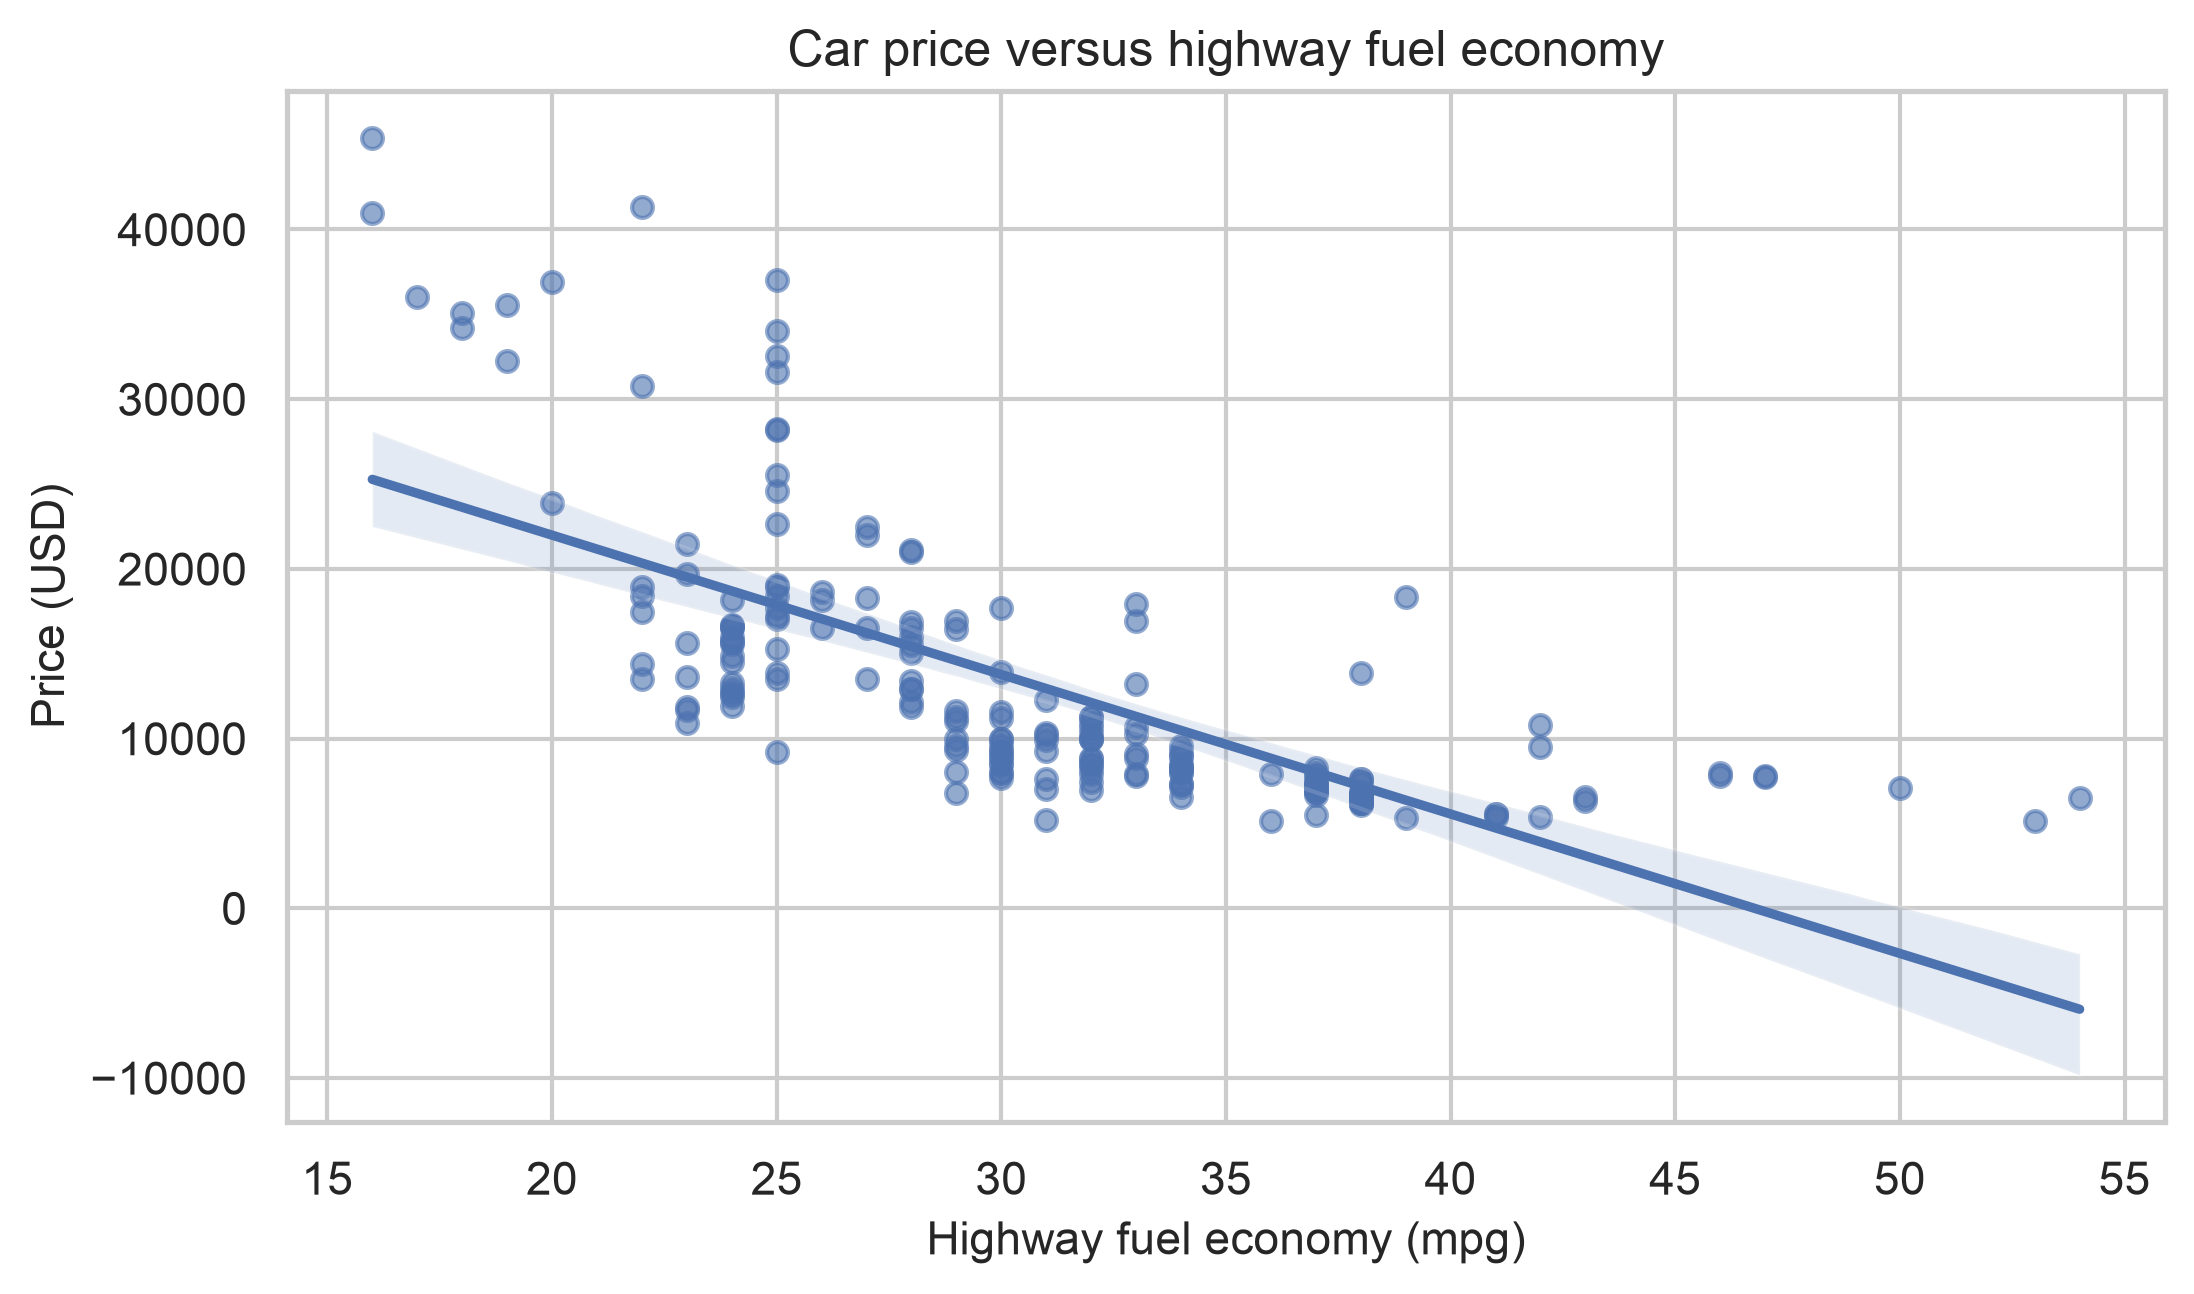

In [27]:
fig, ax = plt.subplots()
sns.regplot(seed=1, x='highway-mpg', y='price', data=df, scatter_kws={'alpha':0.6,'s':25}, ax=ax)
ax.set(title='Car price versus highway fuel economy', xlabel='Highway fuel economy (mpg)', ylabel='Price (USD)')
plt.show()

A negative regression slope indicates an inverse sample association. Scatter around the line indicates the remaining price variation; inspect both direction and dispersion.

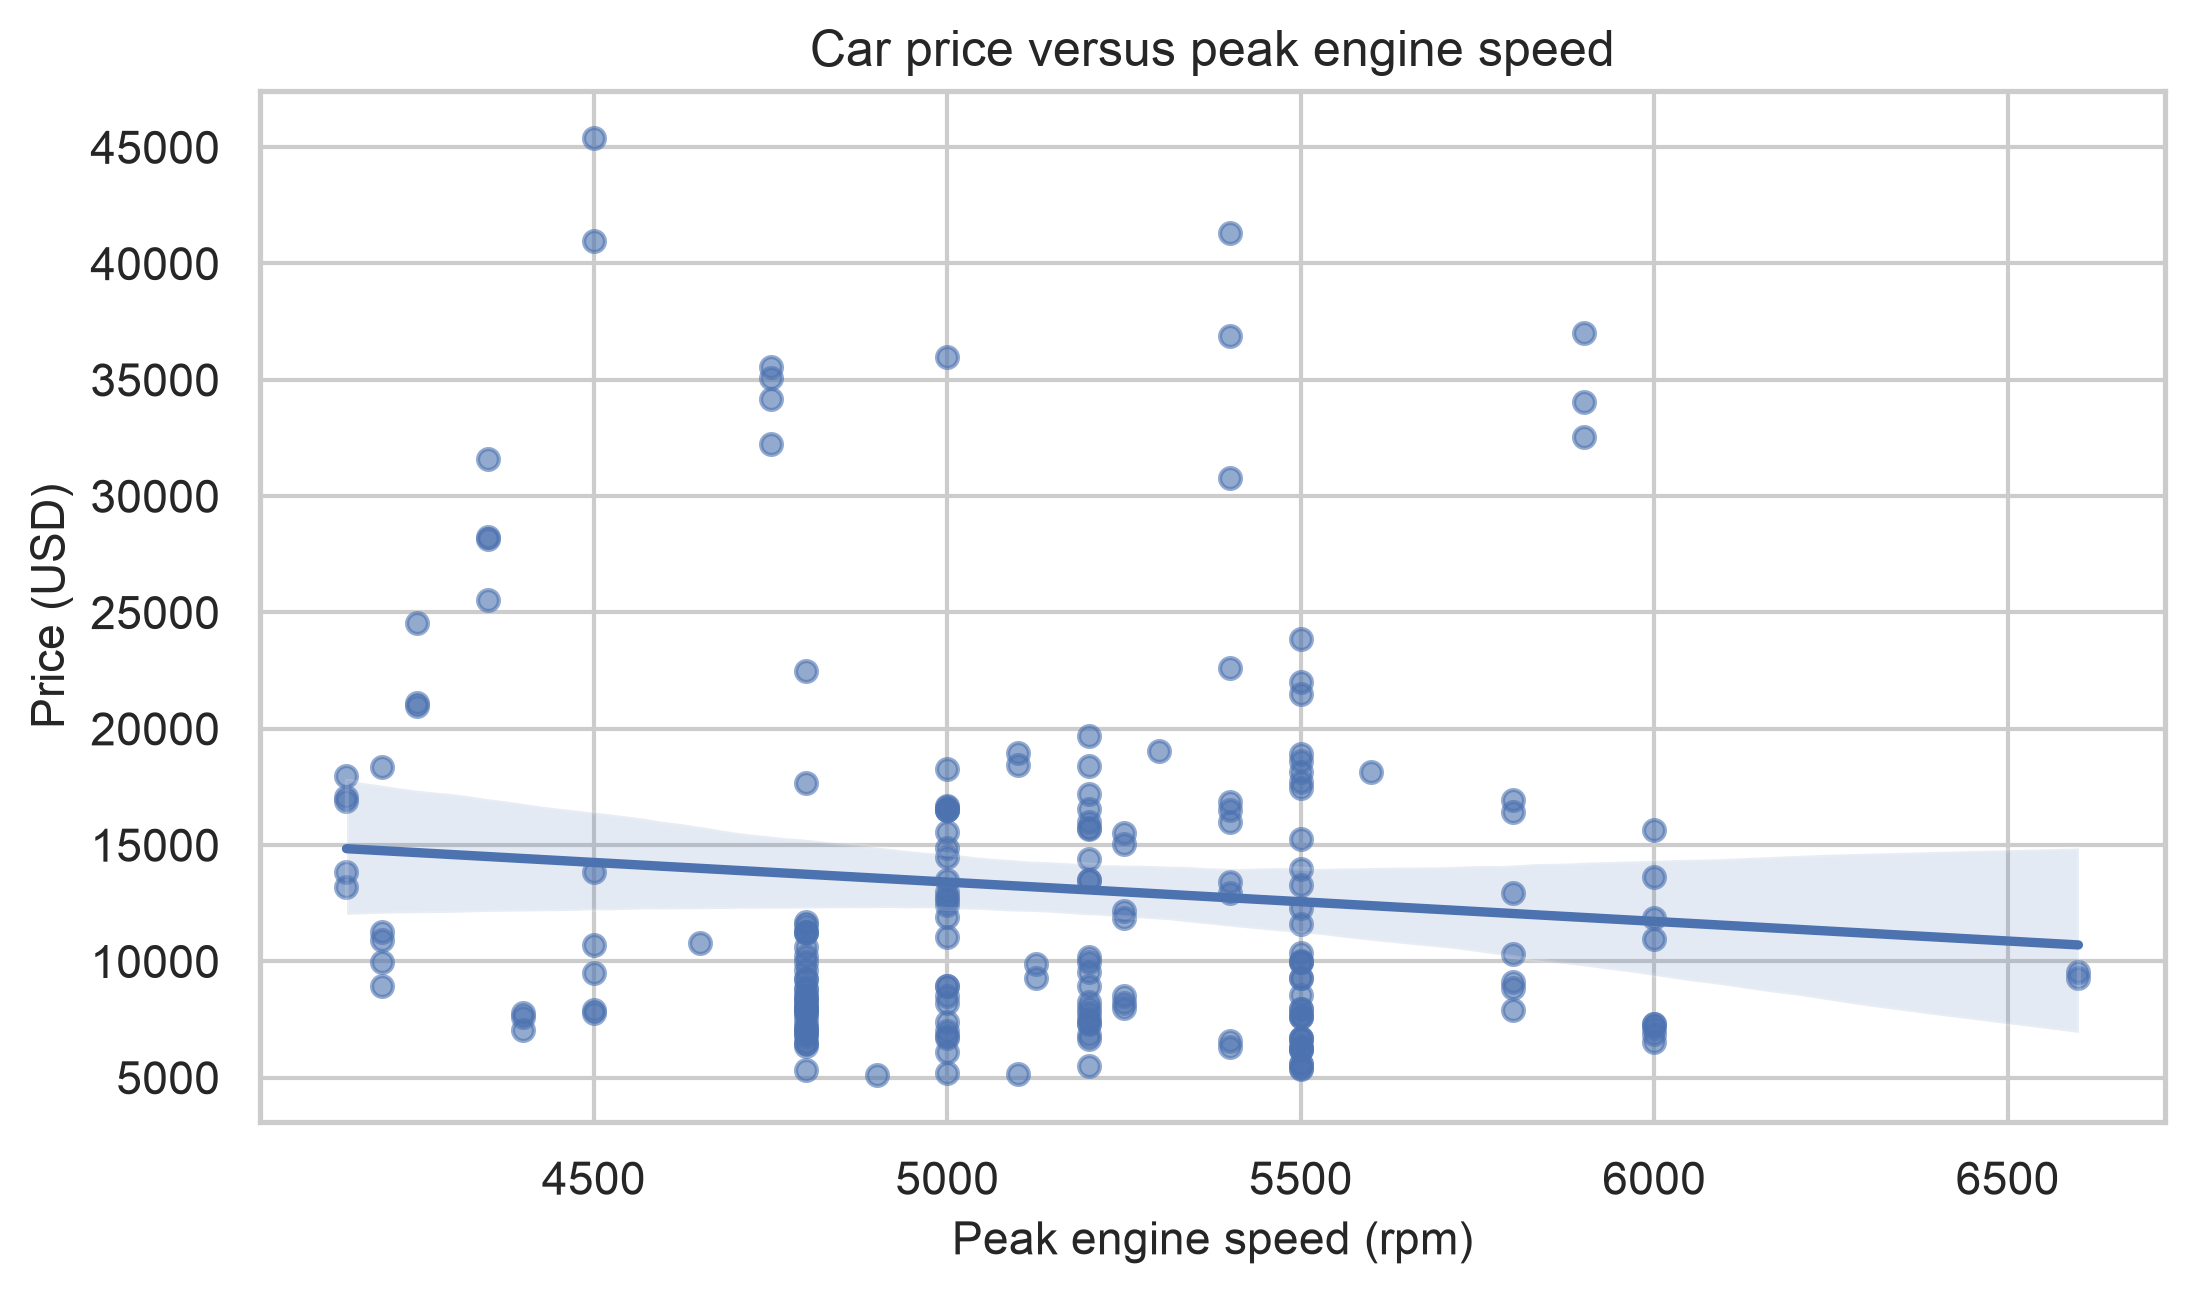

In [28]:
fig, ax = plt.subplots()
sns.regplot(seed=1, x='peak-rpm', y='price', data=df, scatter_kws={'alpha':0.6,'s':25}, ax=ax)
ax.set(title='Car price versus peak engine speed', xlabel='Peak engine speed (rpm)', ylabel='Price (USD)')
plt.show()

The correlation calculation in Question 3 compares these two linear associations numerically.

<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1>Question #3:</h1>
<b>Given the regression plots above, is "peak-rpm" or "highway-mpg" more strongly correlated with "price"? Use the method  ".corr()" to verify your answer.</b>
</div>


In [29]:
correlations = df[['peak-rpm','highway-mpg','price']].corr()
display(correlations)
print(f"Highway-mpg has the stronger linear association: |r|={abs(correlations.loc['highway-mpg','price']):.3f}, versus {abs(correlations.loc['peak-rpm','price']):.3f} for peak-rpm.")
print('These are associations, not causal effects.')

,peak-rpm,highway-mpg,price
peak-rpm,1.0000,-0.0586,-0.1016
highway-mpg,-0.0586,1.0000,-0.7047
price,-0.1016,-0.7047,1.0000


Highway-mpg has the stronger linear association: |r|=0.705, versus 0.102 for peak-rpm.
These are associations, not causal effects.


### Residual plot

A residual is observed minus fitted price. Curvature, uneven spread or extreme residuals can reveal limitations of the fit. A visually random pattern is a diagnostic, not proof that all model assumptions hold.

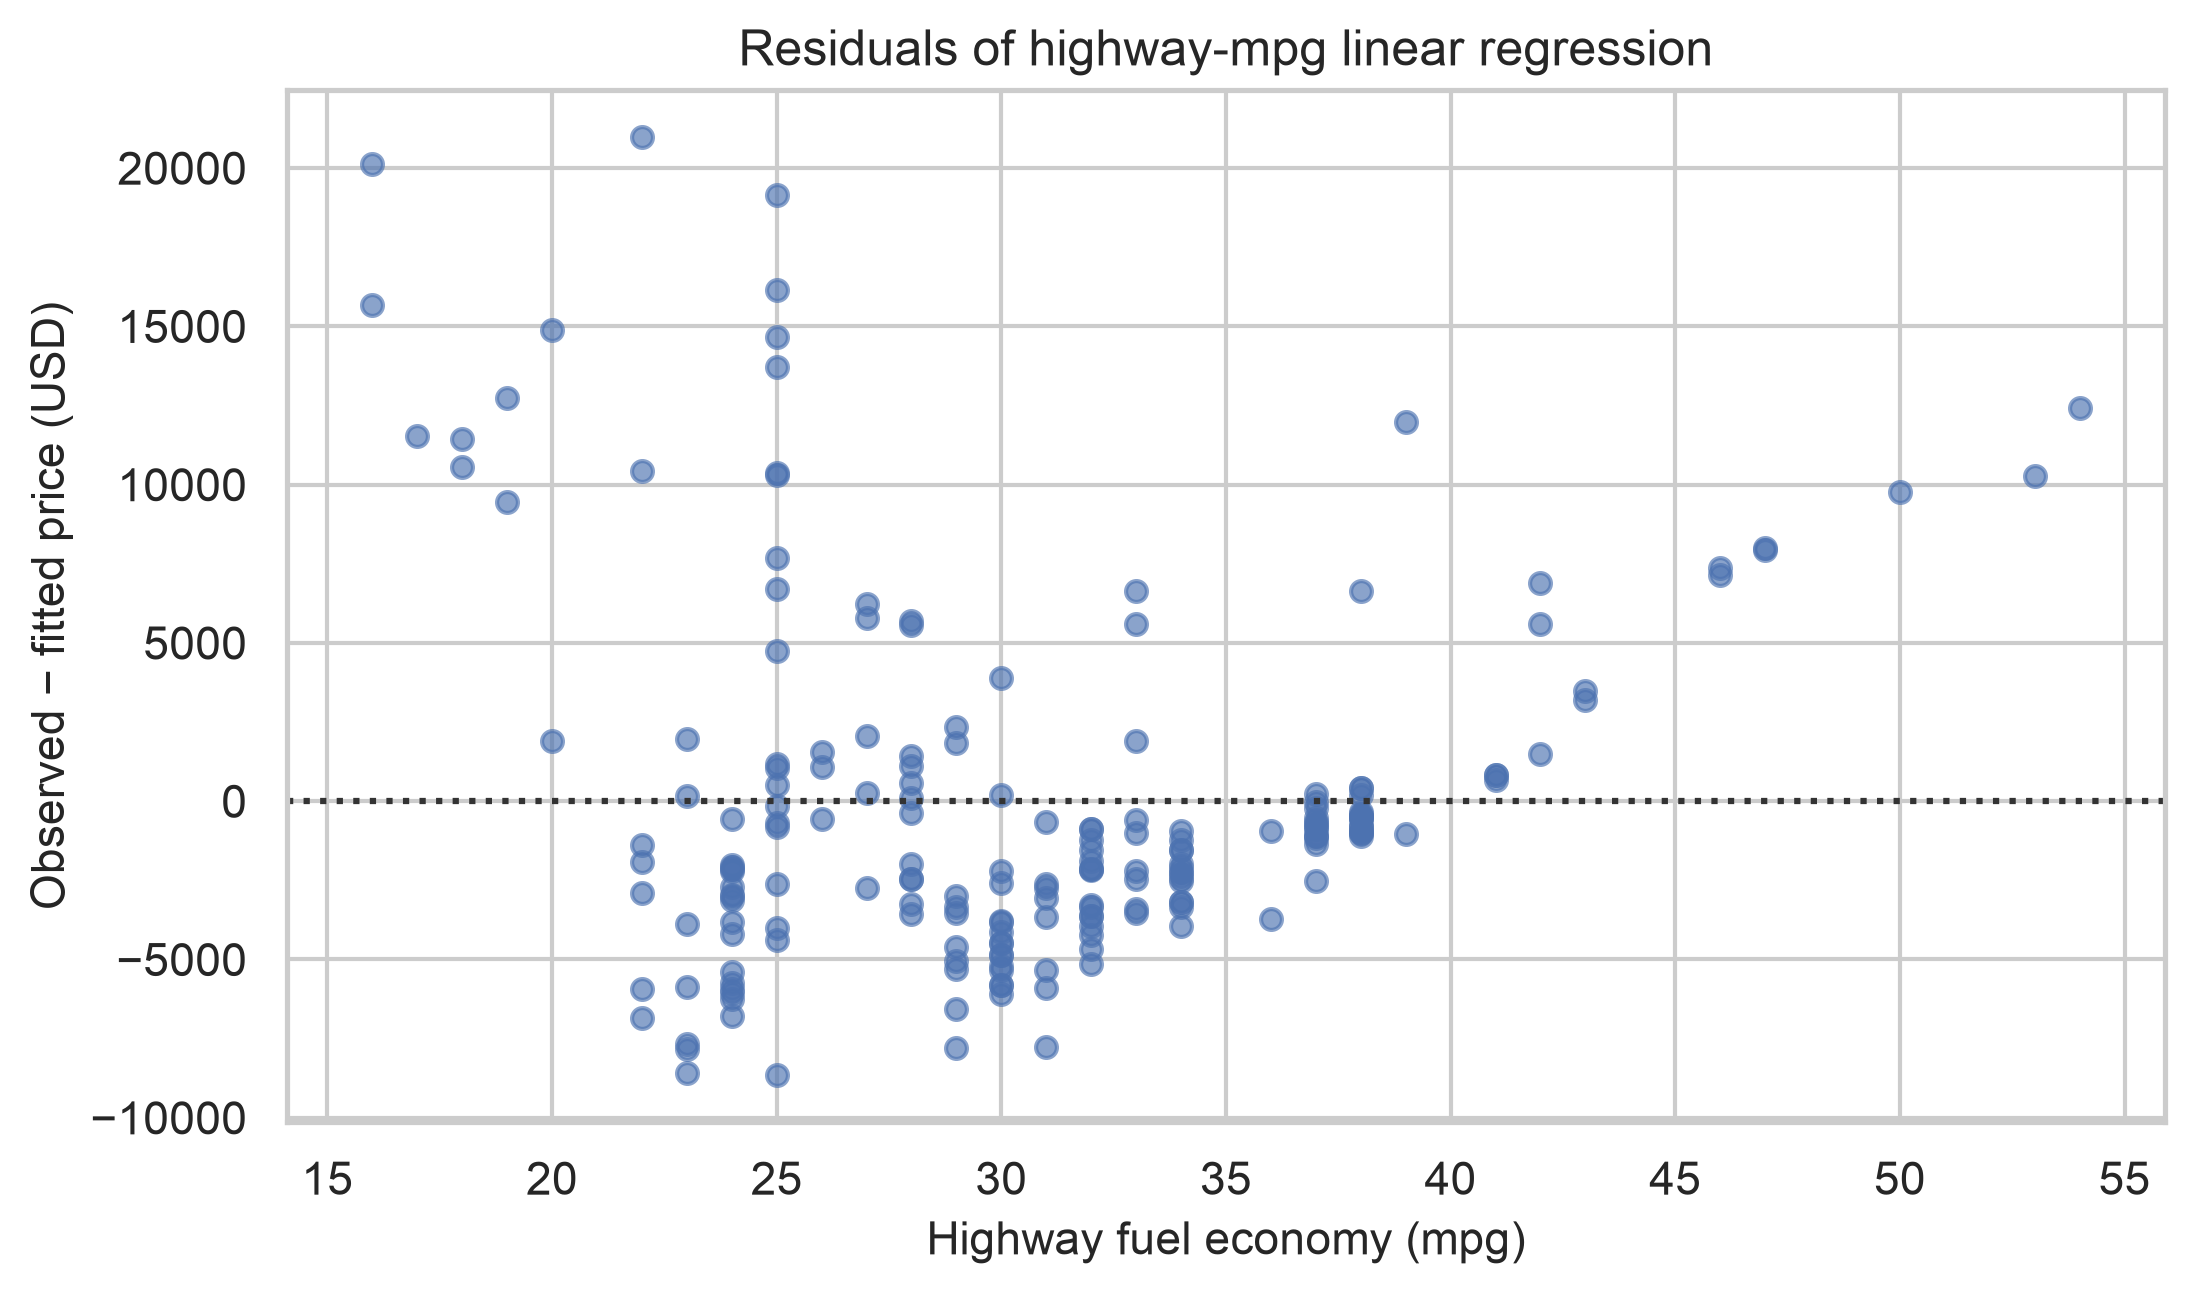

In [30]:
fig, ax = plt.subplots()
sns.residplot(x='highway-mpg', y='price', data=df, scatter_kws={'alpha':0.65,'s':25}, ax=ax)
ax.set(title='Residuals of highway-mpg linear regression', xlabel='Highway fuel economy (mpg)', ylabel='Observed − fitted price (USD)')
plt.show()

The residual view is used to check the linear specification. In particular, the spread and curvature motivate the following polynomial demonstration; they do not by themselves prove that a particular nonlinear model will generalize.

<h3>Multiple Linear Regression</h3>


For multiple regression, compare observed and fitted price distributions. Marginal density overlap does not verify individual prediction accuracy; residuals and paired error metrics provide complementary evidence.

First, let's make a prediction:


In [31]:
Y_hat = lm.predict(Z)

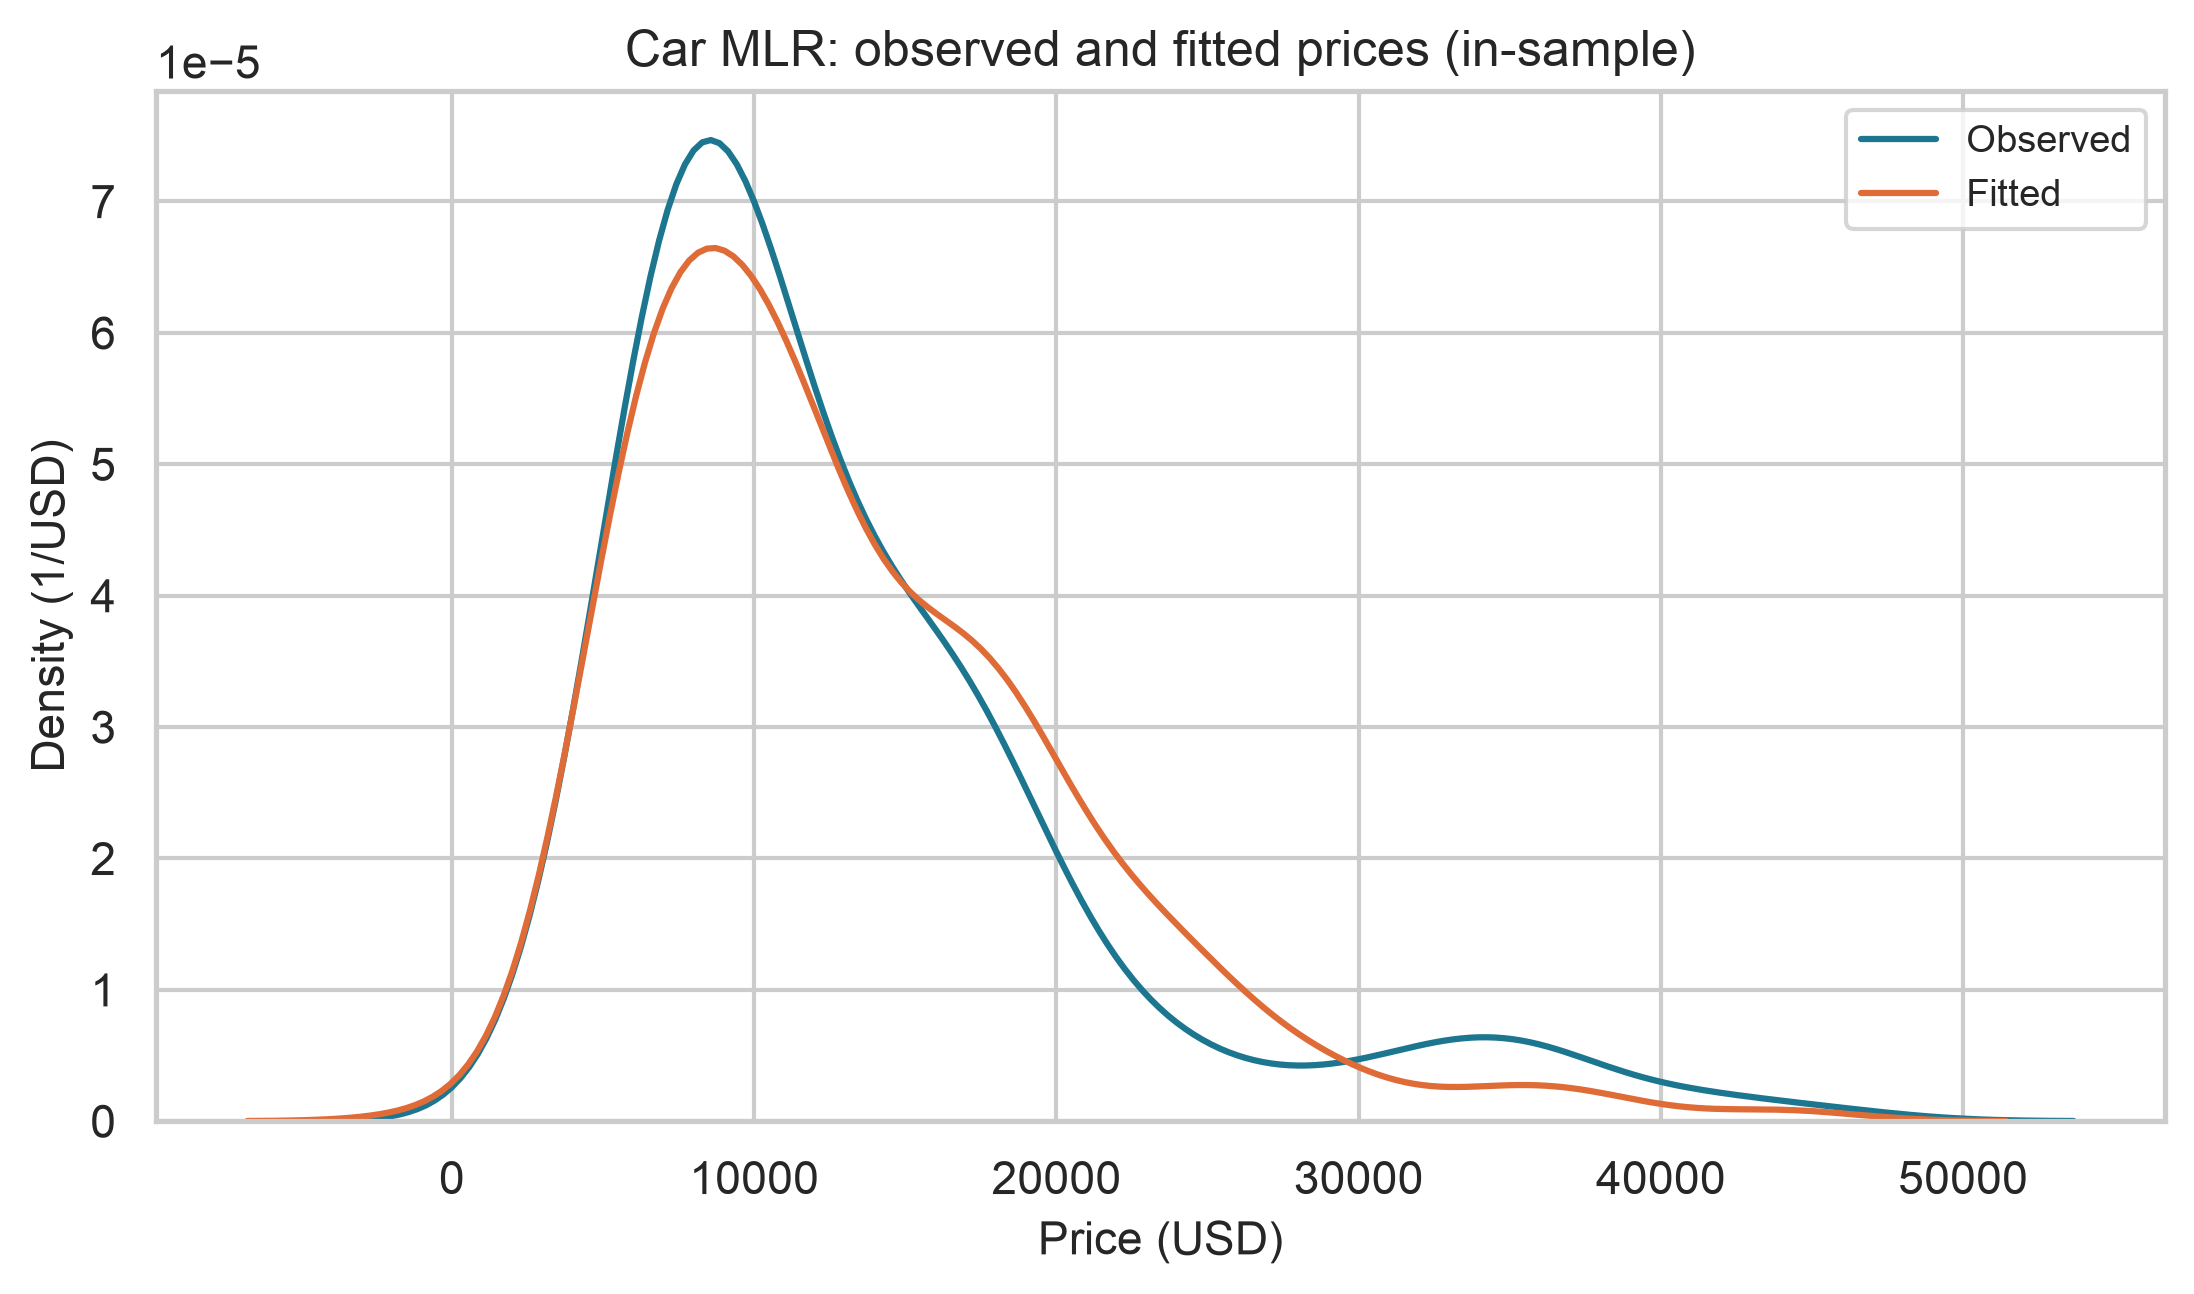

In [32]:
density_plot(df['price'], Y_hat, 'Car MLR: observed and fitted prices (in-sample)')

The density plot summarizes observed and fitted price distributions in the training sample. A smoother, narrower fitted distribution can miss the tails even when its center overlaps the observations.

<h2>3. Polynomial Regression and Pipelines</h2>


<p><b>Polynomial regression</b> is a particular case of the general linear regression model or multiple linear regression models.</p> 
<p>We get non-linear relationships by squaring or setting higher-order terms of the predictor variables.</p>

<p>There are different orders of polynomial regression:</p>


<center><b>Quadratic - 2nd Order</b></center>
$$
Yhat = a + b_1 X +b_2 X^2 
$$


<center><b>Cubic - 3rd Order</b></center>
$$
Yhat = a + b_1 X +b_2 X^2 +b_3 X^3\\\\\\
$$


<center><b>Higher-Order</b>:</center>
$$
Y = a + b_1 X +b_2 X^2 +b_3 X^3 ....\\
$$


<p>We saw earlier that a linear model did not provide the best fit while using "highway-mpg" as the predictor variable. Let's see if we can try fitting a polynomial model to the data instead.</p>


<p>We will use the following function to plot the data:</p>


In [33]:
def PlotPolly(model, independent_variable, dependent_variable, Name):
    x_new = np.linspace(15, 55, 100)
    fig, ax = plt.subplots()
    ax.scatter(independent_variable, dependent_variable, s=22, alpha=0.55, label='Observed')
    ax.plot(x_new, model(x_new), color='#df6b37', label=f'Degree {model.order} fit')
    ax.set(title=f'Car price versus highway mpg: degree {model.order}',
           xlabel=Name, ylabel='Price (USD)')
    ax.legend()
    plt.show()

Let's get the variables:


In [34]:
x = df['highway-mpg']
y = df['price']

Let's fit the polynomial using the function <b>polyfit</b>, then use the function <b>poly1d</b> to display the polynomial function.


In [35]:
# Here we use a polynomial of the 3rd order (cubic) 
f = np.polyfit(x, y, 3)
p = np.poly1d(f)
print(p)

        3         2
-1.557 x + 204.8 x - 8965 x + 1.379e+05


 Let's plot the function:


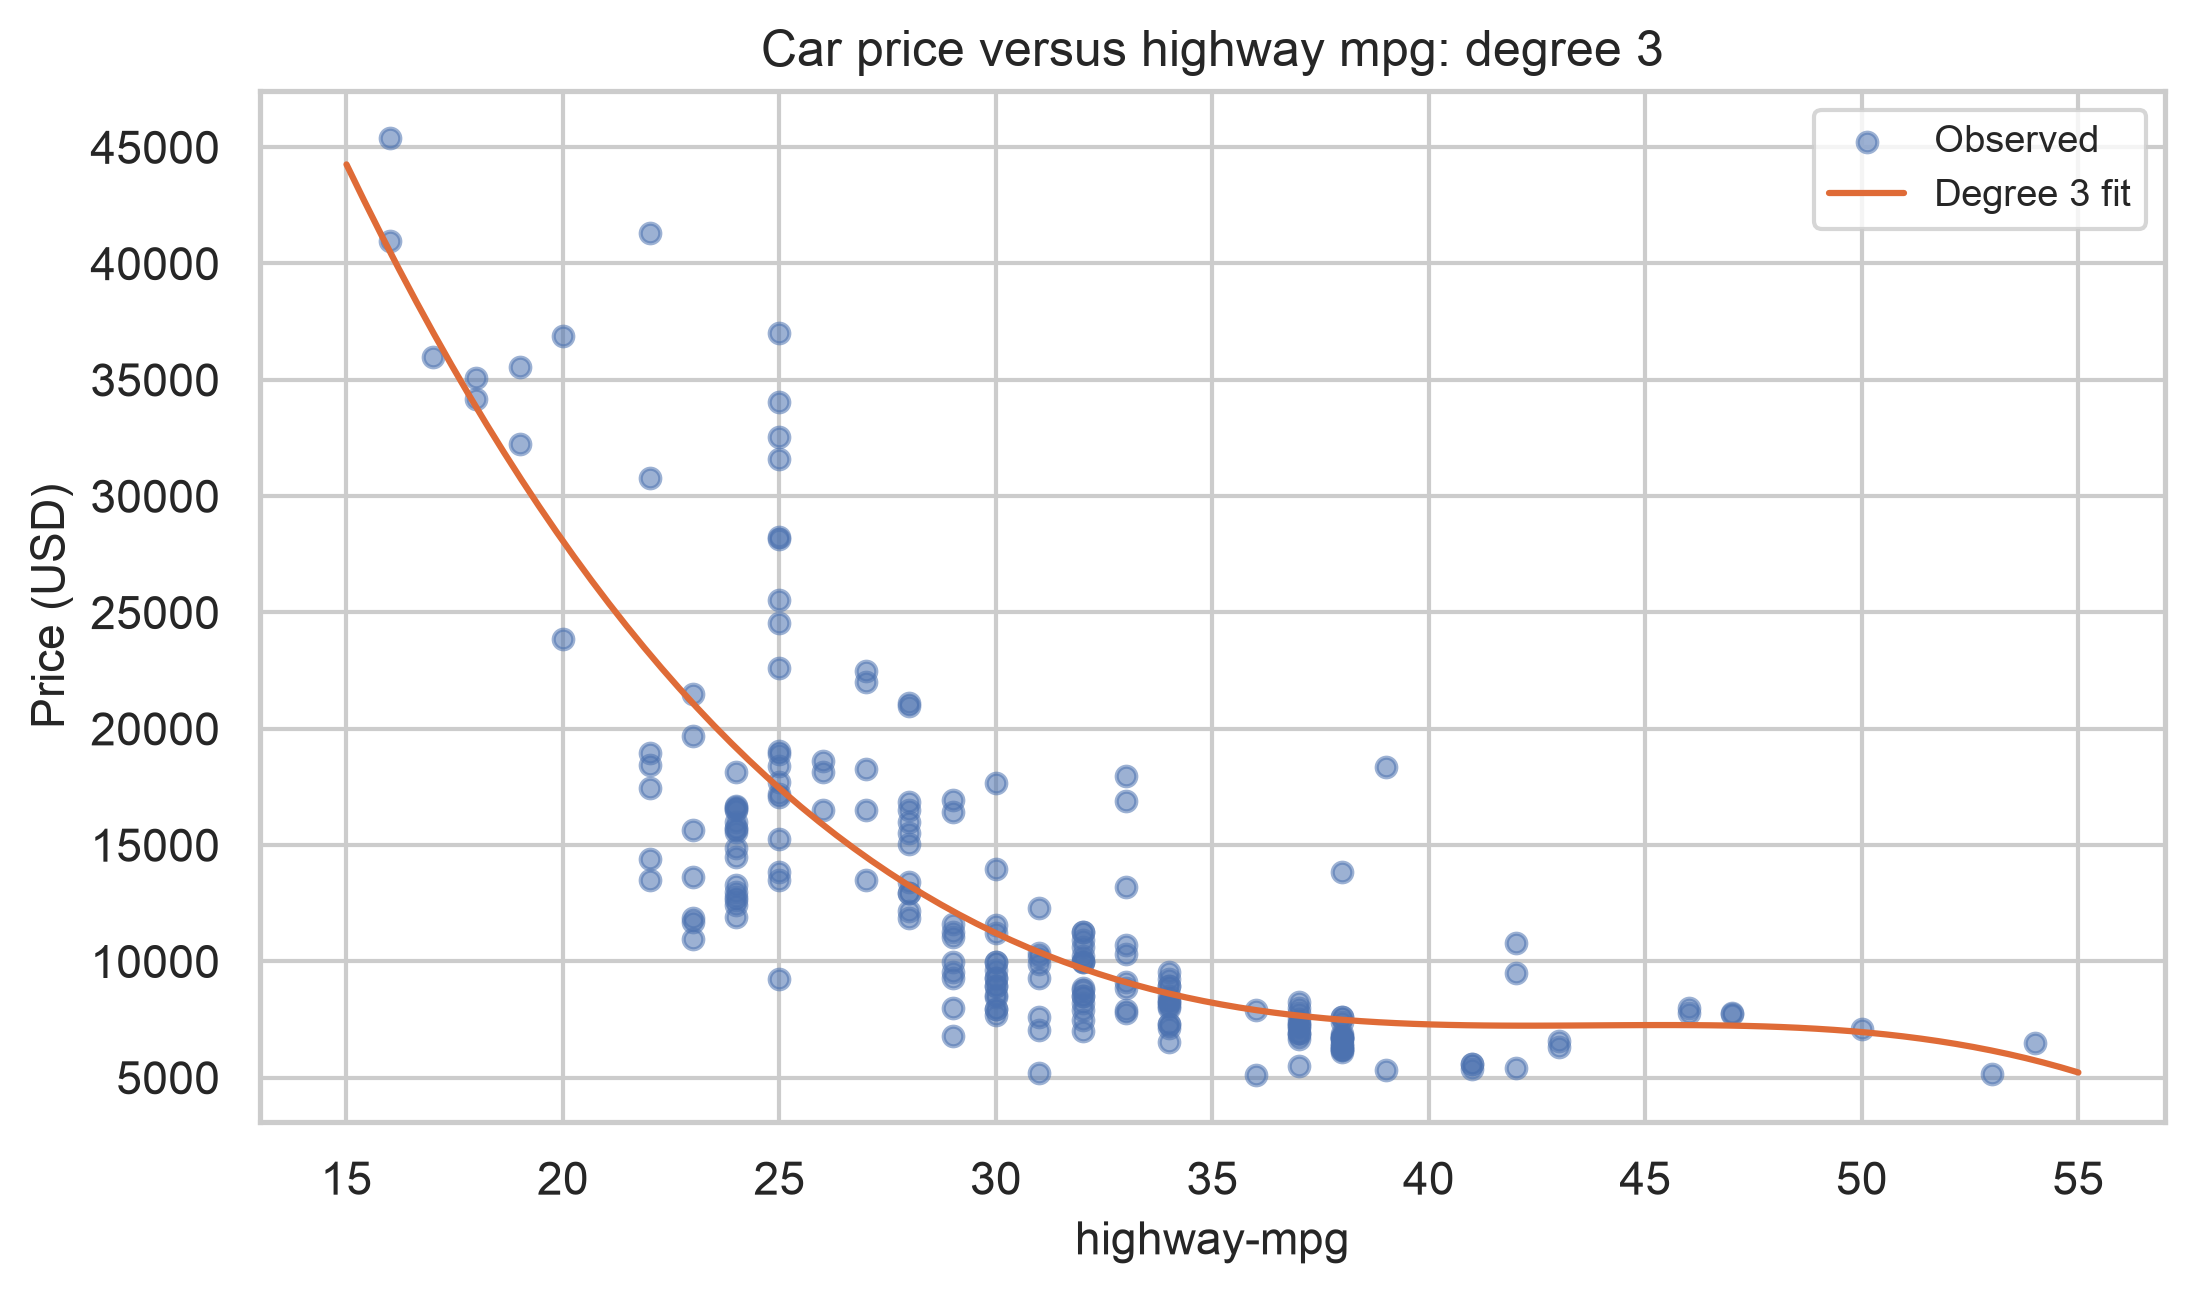

In [36]:
PlotPolly(p, x, y, 'highway-mpg')

In [37]:
np.polyfit(x, y, 3)

array([-1.55663829e+00,  2.04754306e+02, -8.96543312e+03,  1.37923594e+05])

The cubic curve is more flexible than a line. Compare its measured in-sample R² and MSE later; apparent visual fit is not evidence of improved out-of-sample performance.

<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1>Question  #4:</h1>
<b>Create 11 order polynomial model with the variables x and y from above.</b>
</div>


            11             10             9           8         7
-1.243e-08 x  + 4.722e-06 x  - 0.0008028 x + 0.08056 x - 5.297 x
          6        5             4             3             2
 + 239.5 x - 7588 x + 1.684e+05 x - 2.565e+06 x + 2.551e+07 x - 1.491e+08 x + 3.879e+08
Raw Vandermonde condition number: 2.88e+23


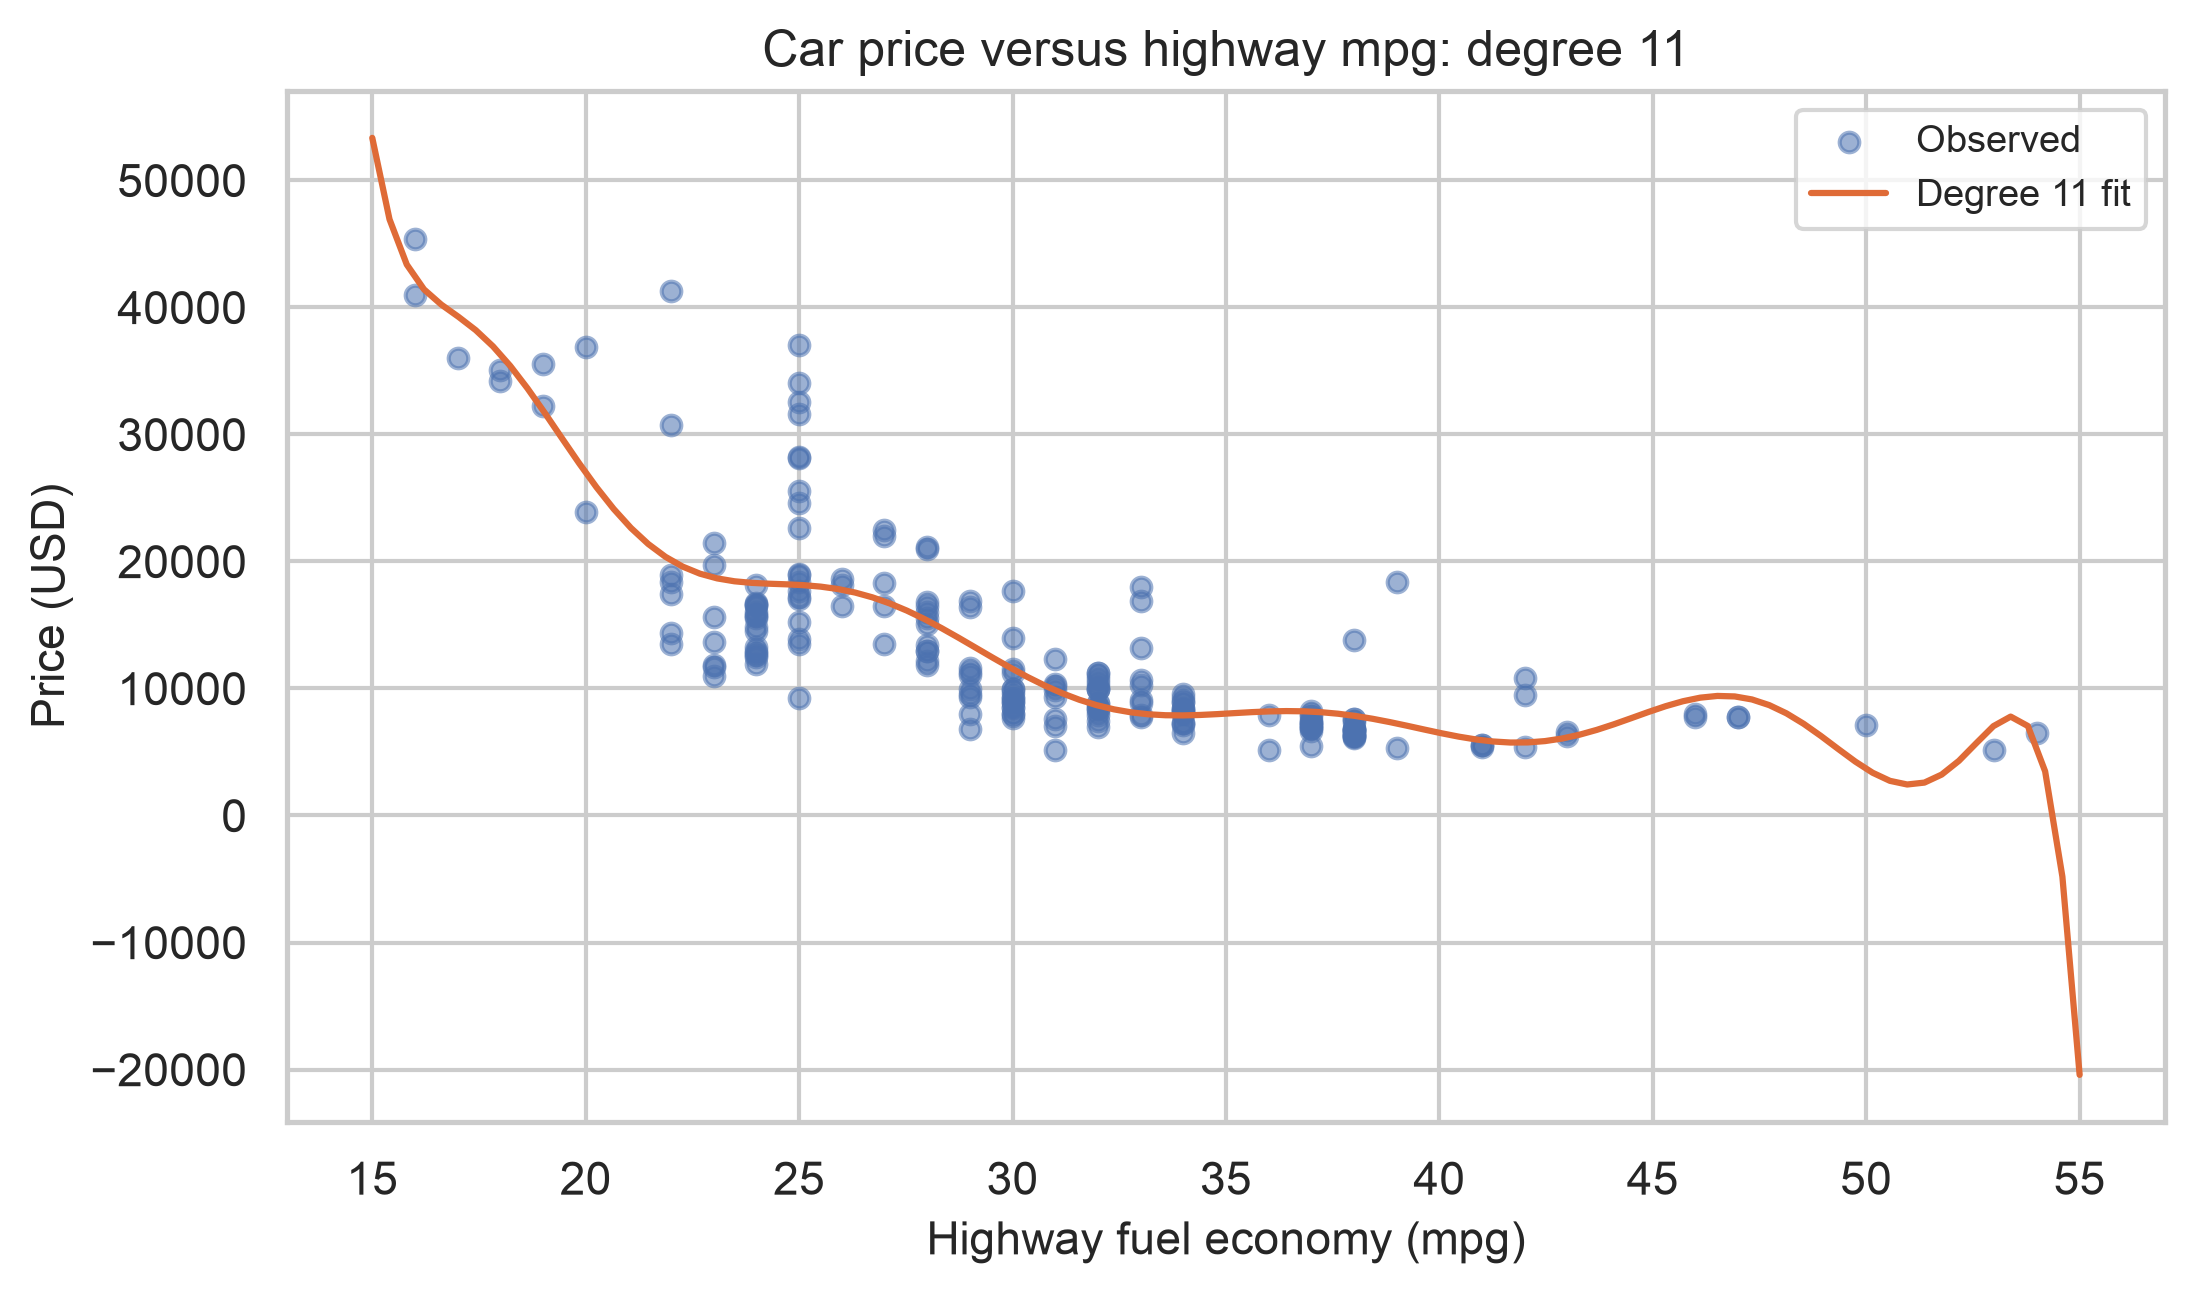

In [38]:
# The required degree is eleven; it is not a cubic polynomial.
f1 = np.polyfit(x, y, 11)
p1 = np.poly1d(f1)
print(p1)
print(f'Raw Vandermonde condition number: {np.linalg.cond(np.vander(x, 12)):.2e}')
PlotPolly(p1, x, y, 'Highway fuel economy (mpg)')

The degree-11 curve is retained as requested. The raw polynomial basis has a large condition number, so coefficients can be sensitive to scaling and rounding. Edge oscillation and extrapolation are unreliable. Higher flexibility alone does not justify selecting this model.

<p>The analytical expression for Multivariate Polynomial function gets complicated. For example, the expression for a second-order (degree=2) polynomial with two variables is given by:</p>


$$
Yhat = a + b_1 X_1 +b_2 X_2 +b_3 X_1 X_2+b_4 X_1^2+b_5 X_2^2
$$


We can perform a polynomial transform on multiple features. First, we import the module:


In [39]:
from sklearn.preprocessing import PolynomialFeatures

We create a <b>PolynomialFeatures</b> object of degree 2: 


In [40]:
pr=PolynomialFeatures(degree=2)
pr

,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'


In [41]:
Z_pr=pr.fit_transform(Z)

The original feature matrix dimensions are printed below.

In [42]:
Z.shape

(201, 4)

The transformed matrix contains the intercept column, four first-order terms and ten second-order terms (squares and interactions).

In [43]:
Z_pr.shape

(201, 15)

<h2>Pipeline</h2>


<p>Data Pipelines simplify the steps of processing the data. We use the module <b>Pipeline</b> to create a pipeline. We also use <b>StandardScaler</b> as a step in our pipeline.</p>


In [44]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

We create the pipeline by creating a list of tuples including the name of the model or estimator and its corresponding constructor.


In [45]:
Input=[('scale',StandardScaler()), ('polynomial', PolynomialFeatures(include_bias=False)), ('model',LinearRegression())]

We input the list as an argument to the pipeline constructor:


In [46]:
pipe=Pipeline(Input)
pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scale', ...), ('polynomial', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'


First, we convert the data type Z to type float to avoid conversion warnings that may appear as a result of StandardScaler taking float inputs.

Then, we can normalize the data,  perform a transform and fit the model simultaneously. 


In [47]:
Z = Z.astype(float)
pipe.fit(Z,y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scale', ...), ('polynomial', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['horsepower','curb-weight','engine-size','highway-mpg']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


 Similarly,  we can normalize the data, perform a transform and produce a prediction  simultaneously.


In [48]:
ypipe=pipe.predict(Z)
ypipe[0:4]

array([13102.74784201, 13102.74784201, 18225.54572197, 10390.29636555])

<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1>Question #5:</h1>
<b>Create a pipeline that standardizes the data, then produce a prediction using a linear regression model using the features Z and target y.</b>
</div>


In [49]:
linear_pipe = Pipeline([('scale', StandardScaler()), ('model', LinearRegression())])
linear_pipe.fit(Z, y)
ylinear_pipe = linear_pipe.predict(Z)
print('First ten predictions (USD):', np.round(ylinear_pipe[:10], 2))

First ten predictions (USD): [13699.11 13699.11 19051.65 10620.36 15521.31 13869.67 15456.16 15974.01
 17612.36 10722.33]


Question 5 omits polynomial features. Standardizing predictors changes their units but, with an unpenalized linear model and intercept, should leave fitted predictions essentially unchanged.

<h2>4. Measures for In-Sample Evaluation</h2>


R² measures reduction in squared error relative to predicting the observed target mean; it can be negative on evaluation data. MSE is the mean squared prediction error in USD². All scores in this module are computed on the fitting sample.

<h3>Model 1: Simple Linear Regression</h3>


Let's calculate the R^2:


In [50]:
lm = LinearRegression().fit(X,Y)
slr = lm
print(f'Highway-mpg SLR in-sample R²: {lm.score(X,Y):.6f}')

Highway-mpg SLR in-sample R²: 0.496591


This score describes **highway-mpg**, not horsepower. The measured explained fraction is summarized in the final comparison table.

Let's calculate the MSE:


We can predict the output i.e., "yhat" using the predict method, where X is the input variable:


In [51]:
Yhat=lm.predict(X)
print('The output of the first four predicted value is: ', Yhat[0:4])

The output of the first four predicted value is:  [16236.50464347 16236.50464347 17058.23802179 13771.3045085 ]


Let's import the function <b>mean_squared_error</b> from the module <b>metrics</b>:


In [52]:
from sklearn.metrics import mean_squared_error

We can compare the predicted results with the actual results:


In [53]:
mse = mean_squared_error(df['price'], Yhat)
print('The mean square error of price and predicted value is: ', mse)

The mean square error of price and predicted value is:  31635042.944639895


<h3>Model 2: Multiple Linear Regression</h3>


Let's calculate the R^2:


In [54]:
lm = LinearRegression().fit(Z,df['price'])
mlr = lm
print(f'Four-feature MLR in-sample R²: {lm.score(Z,df["price"]):.6f}')

Four-feature MLR in-sample R²: 0.809356


This is the in-sample R² of the prescribed four-feature multiple linear regression.

Let's calculate the MSE.


We produce a prediction:


In [55]:
Y_predict_multifit = lm.predict(Z)

We compare the predicted results with the actual results:


In [56]:
print('The mean square error of price and predicted value using multifit is: ', \
      mean_squared_error(df['price'], Y_predict_multifit))

The mean square error of price and predicted value using multifit is:  11980366.87072649


<h3>Model 3: Polynomial Fit</h3>


Let's calculate the R^2.


Let’s import the function <b>r2_score</b> from the module <b>metrics</b> as we are using a different function.


In [57]:
from sklearn.metrics import r2_score

We apply the function to get the value of R^2:


In [58]:
r_squared = r2_score(y, p(x))
print('The R-square value is: ', r_squared)

The R-square value is:  0.6741946663906514


This is the in-sample R² of the cubic highway-mpg fit.

<h3>MSE</h3>


We can also calculate the MSE:  


In [59]:
mean_squared_error(df['price'], p(x))

20474146.426361248

<h2>5. Prediction and Decision Making</h2>
<h3>Prediction</h3>

<p>In the previous section, we trained the model using the method <b>fit</b>. Now we will use the method <b>predict</b> to produce a prediction. Lets import <b>pyplot</b> for plotting; we will also be using some functions from numpy.</p>


In [60]:
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline 

Create a new input:


In [61]:
new_input = pd.DataFrame({'highway-mpg': np.arange(1,100,1)})
print('Prediction grid: highway-mpg from 1 to 99; much of it is outside the data range.')

Prediction grid: highway-mpg from 1 to 99; much of it is outside the data range.


 Fit the model:


In [62]:
lm = LinearRegression().fit(X,Y)
lm

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[-821.73]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['highway-mpg']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.842e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


Produce a prediction:


In [63]:
yhat=lm.predict(new_input)
yhat[0:5]

array([37601.57247984, 36779.83910151, 35958.10572319, 35136.37234487,
       34314.63896655])

We can plot the data:


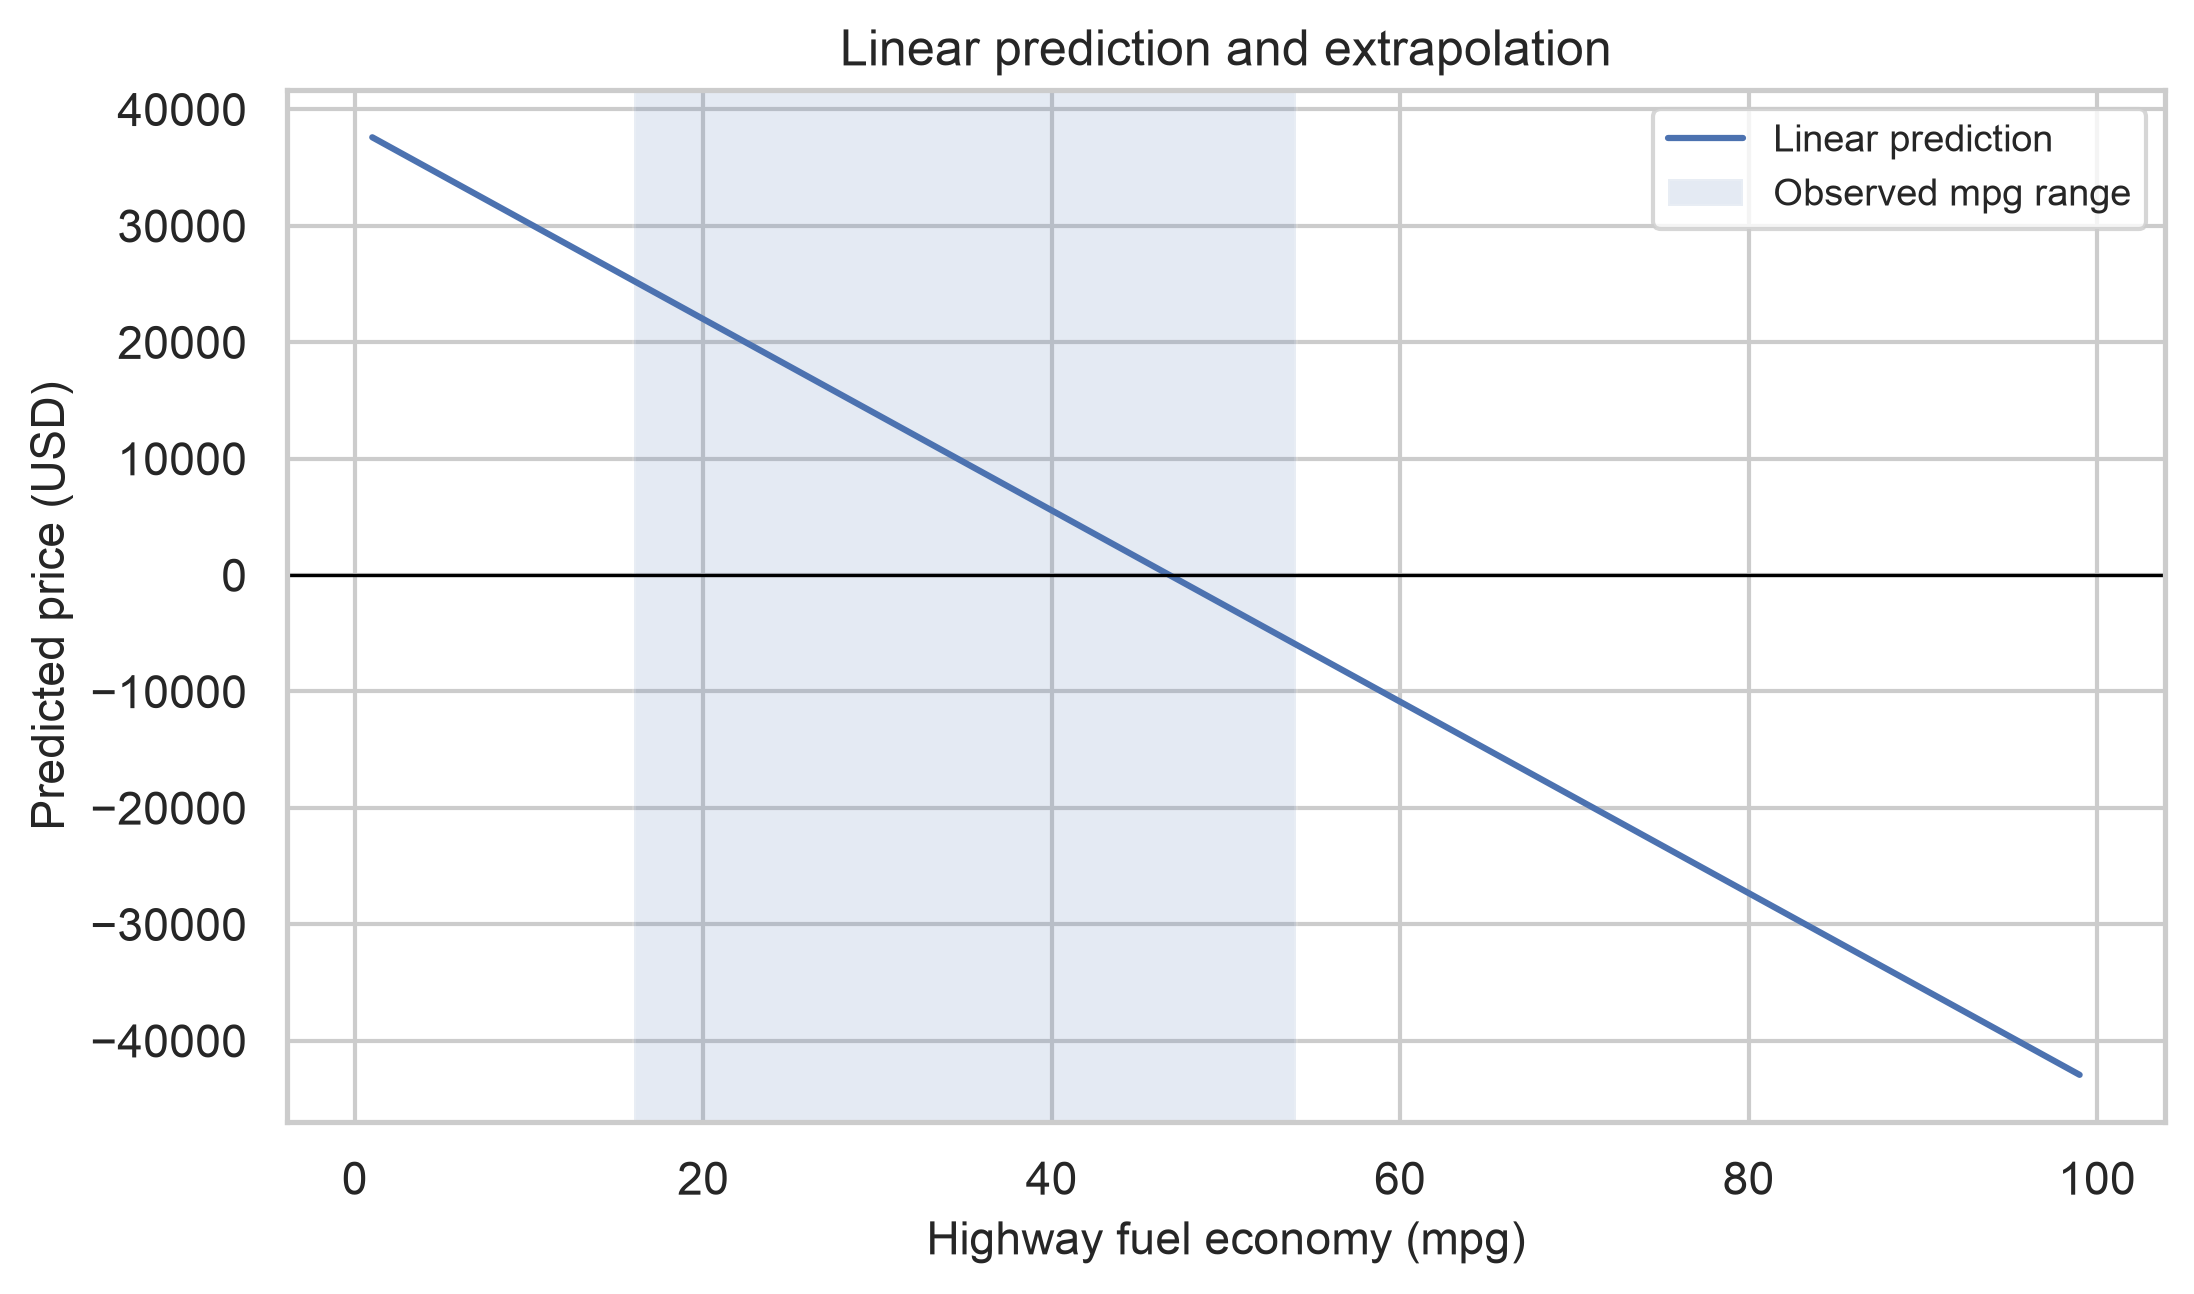

In [64]:
fig, ax = plt.subplots()
ax.plot(new_input['highway-mpg'], yhat, label='Linear prediction')
ax.axvspan(X['highway-mpg'].min(),X['highway-mpg'].max(),alpha=.15,label='Observed mpg range')
ax.axhline(0,color='black',lw=.8)
ax.set(title='Linear prediction and extrapolation',xlabel='Highway fuel economy (mpg)',ylabel='Predicted price (USD)')
ax.legend()
plt.show()

In [65]:
print(f'Observed highway-mpg range: {X.iloc[:,0].min():.0f}–{X.iloc[:,0].max():.0f}')
print(f'Negative predictions on the requested extrapolation grid: {(yhat < 0).sum()} of {len(yhat)}')
print('Negative prices demonstrate why this line should not be extrapolated across the entire 1–99 mpg grid.')

Observed highway-mpg range: 16–54
Negative predictions on the requested extrapolation grid: 53 of 99
Negative prices demonstrate why this line should not be extrapolated across the entire 1–99 mpg grid.


<h3>Decision Making: Determining a Good Model Fit</h3>


Compare measured R² and MSE on the same observations. A higher in-sample R² and lower MSE indicate a closer fit to these data; they do not establish the best predictive model for unseen cars.

In [66]:
comparison = pd.DataFrame([
    metrics_row('Highway-mpg SLR',y,slr.predict(X)),
    metrics_row('Four-feature MLR',y,mlr.predict(Z)),
    metrics_row('Highway-mpg cubic',y,p(x)),
    metrics_row('Highway-mpg degree 11',y,p1(x)),
    metrics_row('Four-feature scaled linear',y,linear_pipe.predict(Z)),
    metrics_row('Four-feature quadratic pipeline',y,pipe.predict(Z))
]).set_index('Model')
display(comparison)
assert np.allclose(linear_pipe.predict(Z),mlr.predict(Z))

,R²,MSE (USD²)
Model,,
Highway-mpg SLR,0.4966,3.1635e+07
Four-feature MLR,0.8094,1.1980e+07
Highway-mpg cubic,0.6742,2.0474e+07
Highway-mpg degree 11,0.7024,1.8703e+07
Four-feature scaled linear,0.8094,1.1980e+07
Four-feature quadratic pipeline,0.8463,9.6566e+06


<h3>Simple Linear Regression Model (SLR) vs Multiple Linear Regression Model (MLR)</h3>


The comparison table shows the measured improvement from using the four prescribed features instead of highway mpg alone. The models differ in both information available and complexity.

<h3>Simple Linear Model (SLR) vs. Polynomial Fit</h3>


The cubic fit allows curvature in the highway-mpg relationship. Its comparison with the straight line holds the source observations and predictor fixed.

<h3>Multiple Linear Regression (MLR) vs. Polynomial Fit</h3>


The multivariable model and univariate cubic use different information. Their in-sample comparison describes fit, not the isolated causal benefit of adding predictors.

<h2>Conclusion</h2>


The conclusion below uses the regenerated metrics. Validation on unseen data is the next module’s task; current prices and causal effects are outside the scope of this historical educational snapshot.

In [67]:
base = comparison.loc[['Highway-mpg SLR','Four-feature MLR','Highway-mpg cubic']]
best_base = base['MSE (USD²)'].idxmin()
print(f'Among the three main models, {best_base} gives the smallest in-sample MSE: '
      f"{base.loc[best_base,'MSE (USD²)']:,.0f} USD² (R²={base.loc[best_base,'R²']:.3f}).")
print('Additional polynomial terms can reduce training error, but validation is needed before choosing a predictive model.')

Among the three main models, Four-feature MLR gives the smallest in-sample MSE: 11,980,367 USD² (R²=0.809).
Additional polynomial terms can reduce training error, but validation is needed before choosing a predictive model.


### Thank you for completing this lab!


## Author

<a href="https://www.linkedin.com/in/joseph-s-50398b136/" target="_blank">Joseph Santarcangelo</a>


### Other Contributors

<a href="https://www.linkedin.com/in/mahdi-noorian-58219234/" target="_blank">Mahdi Noorian PhD</a>

Bahare Talayian

Eric Xiao

Steven Dong

Parizad

Hima Vasudevan

<a href="https://www.linkedin.com/in/fiorellawever/" target="_blank">Fiorella Wenver</a>

<a href=" https://www.linkedin.com/in/yi-leng-yao-84451275/ " target="_blank" >Yi Yao</a>.

<a href="https://www.coursera.org/instructor/~129186572" target = "_blank" > Abhishek Gagneja</a>

## <h3 align="center"> © IBM Corporation 2023. All rights reserved. <h3/>
<!--

## Change Log


|  Date (YYYY-MM-DD) |  Version | Changed By  |  Change Description |
|---|---|---|---|
| 2023-09-28 | 2.3 | Abhishek Gagneja | Updated instructions |
| 2020-10-30  | 2.2  | Lakshmi  |Changed url of csv  |
| 2020-09-09  | 2.1  | Lakshmi  | Fixes made in Polynomial Regression Equations  |
| 2020-08-27  | 2.0  | Lavanya  |  Moved lab to course repo in GitLab  |



--!>
<hr>

